# 🕵️‍♂️ Notebook de comprobaciones: Flujo y resolución de imágenes

Este notebook permite comprobar que no se pierde resolución ni calidad en el flujo de procesado de imágenes del proyecto. Se sigue el camino desde la carpeta original hasta la imagen final almacenada y registrada en la base de datos.

## 1. Importar librerías necesarias

Importamos las librerías para manejo de imágenes, rutas y visualización.

In [1]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Si necesitas OpenCV: import cv2

## 2. Cargar imágenes de ejemplo

Seleccionamos varias imágenes de ejemplo desde las carpetas originales (`data/Imported/`, `data/PlantVillage/`, etc.) para seguir su flujo.

In [17]:
# Cambia el directorio de trabajo al raíz del repo si es necesario
import os
import random

# Ajusta el path base según dónde ejecutes el notebook
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Directorio base usado: {base_dir}")

vrain_dir = os.path.join(base_dir, 'data/Imported/VRAIN_Viticultura_Enologia/color/Vid___Enrollamiento_Virotico/')
plant_dir = os.path.join(base_dir, 'data/PlantVillage/grayscale/Apple___healthy/')

# Buscar imágenes en los directorios
extensiones = ('.jpg', '.jpeg', '.png')
vrain_imgs = [os.path.join(vrain_dir, f) for f in os.listdir(vrain_dir) if f.lower().endswith(extensiones)] if os.path.exists(vrain_dir) else []
plant_imgs = [os.path.join(plant_dir, f) for f in os.listdir(plant_dir) if f.lower().endswith(extensiones)] if os.path.exists(plant_dir) else []

# Seleccionar la mayoría de VRAIN y 1-2 de PlantVillage
n_vrain = min(4, len(vrain_imgs))
n_plant = min(2, len(plant_imgs))
imagenes_ejemplo = random.sample(vrain_imgs, n_vrain) if n_vrain > 0 else []
if n_plant > 0:
    imagenes_ejemplo += random.sample(plant_imgs, n_plant)

print("Imágenes seleccionadas:", imagenes_ejemplo)

Directorio base usado: c:\Users\Pablo\Documents\Universidad\TFG\Repositorios\Repo
Imágenes seleccionadas: ['c:\\Users\\Pablo\\Documents\\Universidad\\TFG\\Repositorios\\Repo\\data/Imported/VRAIN_Viticultura_Enologia/color/Vid___Enrollamiento_Virotico/Virus. Enrollamiento Virotico0001.jpg', 'c:\\Users\\Pablo\\Documents\\Universidad\\TFG\\Repositorios\\Repo\\data/Imported/VRAIN_Viticultura_Enologia/color/Vid___Enrollamiento_Virotico/Virus. Enrollamiento Virotico0008.jpg', 'c:\\Users\\Pablo\\Documents\\Universidad\\TFG\\Repositorios\\Repo\\data/Imported/VRAIN_Viticultura_Enologia/color/Vid___Enrollamiento_Virotico/Virus. Enrollamiento Virotico0007.jpg', 'c:\\Users\\Pablo\\Documents\\Universidad\\TFG\\Repositorios\\Repo\\data/Imported/VRAIN_Viticultura_Enologia/color/Vid___Enrollamiento_Virotico/Virus. Enrollamiento Virotico0009.jpg', 'c:\\Users\\Pablo\\Documents\\Universidad\\TFG\\Repositorios\\Repo\\data/PlantVillage/grayscale/Apple___healthy/f864bef8-0fb1-43e1-866f-a1e78336be9f___RS_HL 

## 3. Seguir el flujo de procesamiento de imágenes

Simulamos el flujo de procesamiento que sigue cada imagen en el proyecto, aplicando los mismos pasos que se usan normalmente (por ejemplo, redimensionado, cambio de formato, guardado en `/imagenes`, etc.).

In [18]:
# Simulación del flujo: original -> procesada -> almacenada
# (Ajusta los pasos según tu pipeline real)
procesadas = []
for img_path in imagenes_ejemplo:
    try:
        img = Image.open(img_path)
        original_size = img.size
        # Simula un procesamiento típico (por ejemplo, redimensionado)
        img_proc = img.resize((224, 224))  # Ajusta si tu pipeline usa otro tamaño
        proc_size = img_proc.size
        # Simula guardado en /imagenes (no se guarda realmente, solo para comprobar)
        procesadas.append({
            'ruta_original': img_path,
            'resolucion_original': original_size,
            'resolucion_procesada': proc_size
        })
    except Exception as e:
        print(f"Error con {img_path}: {e}")

procesadas_df = pd.DataFrame(procesadas)
procesadas_df

,ruta_original,resolucion_original,resolucion_procesada
0,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(1196, 1796)","(224, 224)"
1,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(1197, 1797)","(224, 224)"
2,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(1196, 1796)","(224, 224)"
3,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(1196, 1796)","(224, 224)"
4,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(256, 256)","(224, 224)"
5,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(256, 256)","(224, 224)"


## 4. Comprobar la resolución en cada etapa

Registramos y mostramos la resolución de cada imagen antes y después del procesamiento para detectar posibles pérdidas de tamaño.

In [19]:
# Mostrar diferencias de resolución
if not procesadas_df.empty:
    print("Comparativa de resoluciones (original vs procesada):")
    display(procesadas_df)
    cambios = procesadas_df[procesadas_df['resolucion_original'] != procesadas_df['resolucion_procesada']]
    if not cambios.empty:
        print("\nImágenes que han cambiado de resolución:")
        display(cambios)
    else:
        print("\nNo se detectaron cambios de resolución en la muestra.")
else:
    print("No se pudieron procesar imágenes de la muestra.")

Comparativa de resoluciones (original vs procesada):


,ruta_original,resolucion_original,resolucion_procesada
0,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(1196, 1796)","(224, 224)"
1,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(1197, 1797)","(224, 224)"
2,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(1196, 1796)","(224, 224)"
3,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(1196, 1796)","(224, 224)"
4,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(256, 256)","(224, 224)"
5,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(256, 256)","(224, 224)"



Imágenes que han cambiado de resolución:


,ruta_original,resolucion_original,resolucion_procesada
0,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(1196, 1796)","(224, 224)"
1,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(1197, 1797)","(224, 224)"
2,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(1196, 1796)","(224, 224)"
3,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(1196, 1796)","(224, 224)"
4,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(256, 256)","(224, 224)"
5,c:\Users\Pablo\Documents\Universidad\TFG\Repos...,"(256, 256)","(224, 224)"


## 5. Visualizar y comparar imágenes

Mostramos visualmente las imágenes originales y procesadas para comprobar visualmente si hay pérdida de calidad o tamaño.

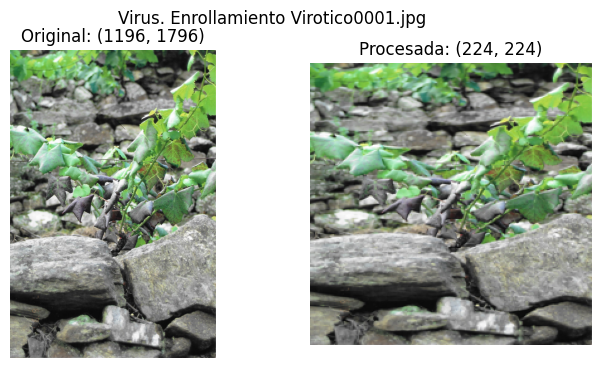

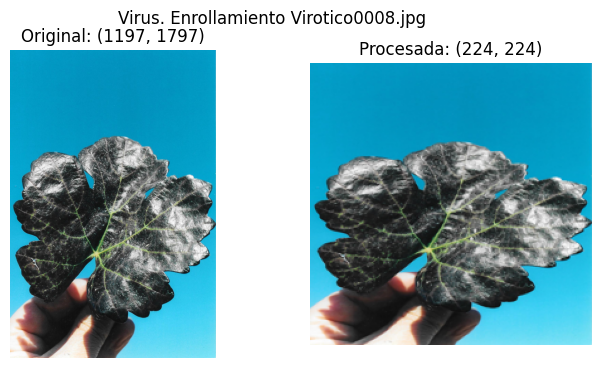

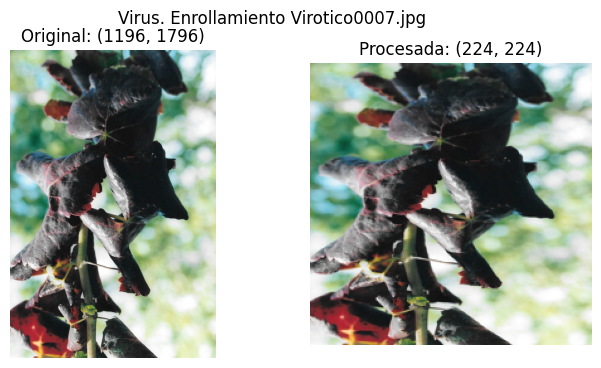

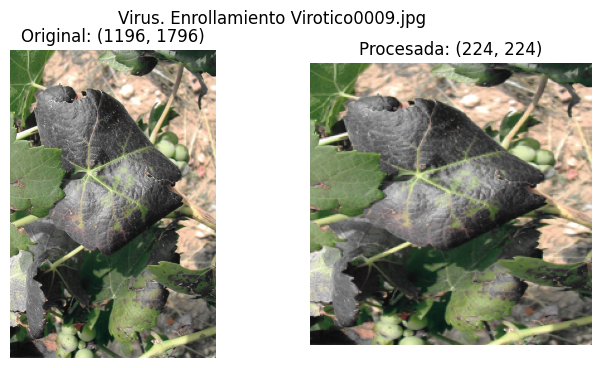

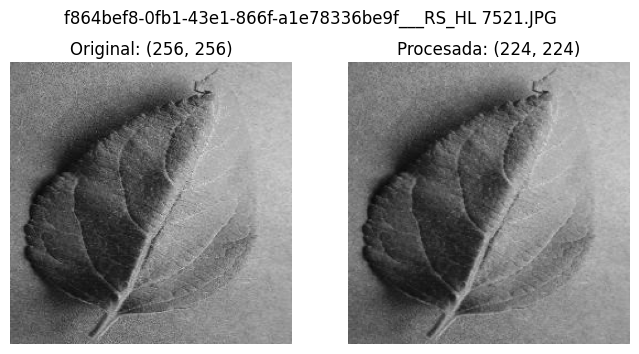

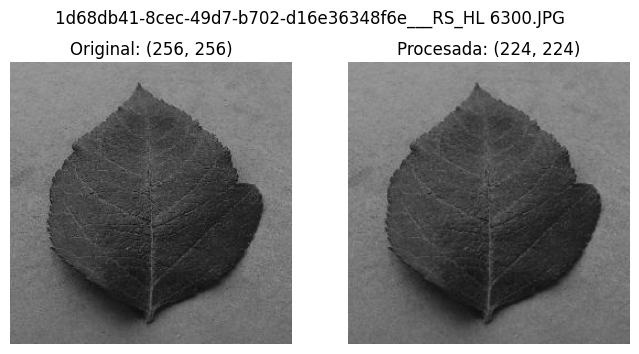

In [20]:
# Visualización de imágenes originales y procesadas
for i, row in procesadas_df.iterrows():
    try:
        img_orig = Image.open(row['ruta_original'])
        img_proc = img_orig.resize((224, 224))  # Simula el procesamiento
        fig, axs = plt.subplots(1, 2, figsize=(8, 4))
        axs[0].imshow(img_orig)
        axs[0].set_title(f'Original: {row["resolucion_original"]}')
        axs[0].axis('off')
        axs[1].imshow(img_proc)
        axs[1].set_title(f'Procesada: {row["resolucion_procesada"]}')
        axs[1].axis('off')
        plt.suptitle(os.path.basename(row['ruta_original']))
        plt.show()
    except Exception as e:
        print(f"Error mostrando {row['ruta_original']}: {e}")